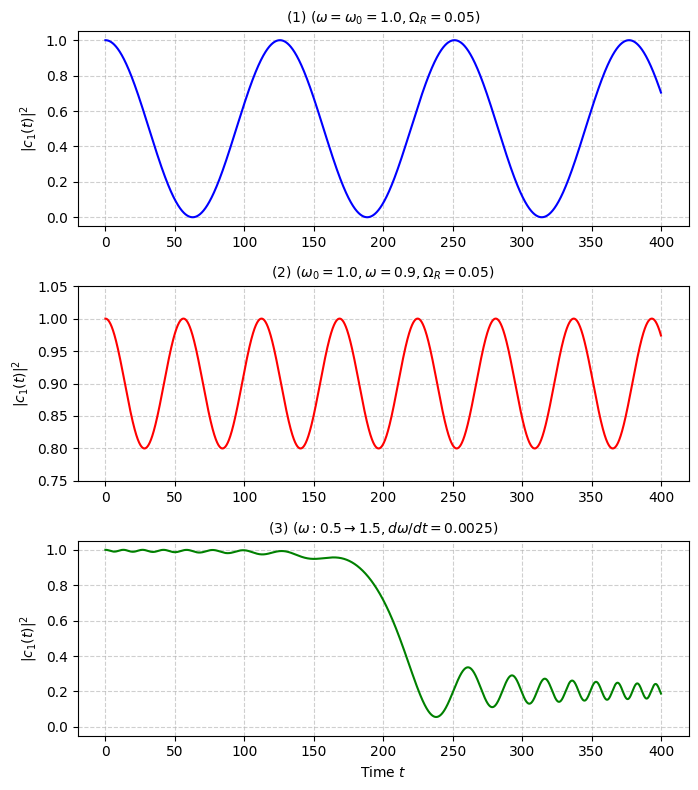

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def solve_system(omega_func, omega0, Omega_R, t_span, dt=0.01):
    t_eval = np.arange(t_span[0], t_span[1], dt)
    c_0 = np.array([1.0+0.0j, 0.0+0.0j]) # 初期条件→(c1(0)=1, c2(0)=0)
    c1_probability = []

    def right_hand_side(t, c_vec):
        w = omega_func(t)
        detuning = w-omega0 # 離調(デチュー二ング)
        H = 0.5*np.array([[-detuning, Omega_R], [Omega_R, detuning]], dtype=complex) # ハミルトニアン
        return -1j*H @ c_vec

    for t in t_eval:
        c1_probability.append(np.abs((c_0[0])**2))
        # 4次ルンゲ=クッタ法(RK4)
        k1 = right_hand_side(t, c_0)
        k2 = right_hand_side(t+0.5*dt, c_0+0.5*dt*k1)
        k3 = right_hand_side(t+0.5*dt, c_0+0.5*dt*k2)
        k4 = right_hand_side(t+dt, c_0+dt*k3)
        c_0 += (dt/6.0)*(k1+2*k2+2*k3+k4)

    return t_eval, np.array(c1_probability), c_0

def omega_func_1(t):
    return 1.0

def omega_func_2(t):
    return 0.9

t_max = 400.0
dw_dt = (1.5-0.5)/t_max
def omega_func_3(t):
    return 0.5+dw_dt*t

# (1)共鳴状態
t1, p1, _ = solve_system(omega_func_1, omega0=1.0, Omega_R=0.05, t_span=(0, t_max), dt=0.01)
# (2)離調状態
t2, p2, _ = solve_system(omega_func_2, omega0=1.0, Omega_R=0.05, t_span=(0, t_max), dt=0.01)
# (3)断熱遷移
t3, p3, _ = solve_system(omega_func_3, omega0=1.0, Omega_R=0.05, t_span=(0, t_max), dt=0.01)

fig, axs = plt.subplots(3, 1, figsize=(7, 8), sharex=False)

axs[0].plot(t1, p1, color='b', linewidth=1.5)
axs[0].set_title(r'(1) ($\omega = \omega_0 = 1.0, \Omega_R = 0.05$)', fontsize=10)
axs[0].set_ylabel(r'$|c_1(t)|^2$', fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].set_ylim(-0.05, 1.05)

axs[1].plot(t2, p2, color='r', linewidth=1.5)
axs[1].set_title(r'(2) ($\omega_0 = 1.0, \omega = 0.9, \Omega_R = 0.05$)', fontsize=10)
axs[1].set_ylabel(r'$|c_1(t)|^2$', fontsize=10)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].set_ylim(0.75, 1.05)

axs[2].plot(t3, p3, color='g', linewidth=1.5)
axs[2].set_title(r'(3) ($\omega: 0.5 \rightarrow 1.5, d\omega/dt = 0.0025$)', fontsize=10)
axs[2].set_xlabel(r'Time $t$', fontsize=10)
axs[2].set_ylabel(r'$|c_1(t)|^2$', fontsize=10)
axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("atomic_physics_inoue_plot.pdf", dpi=300)
plt.show()